In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch

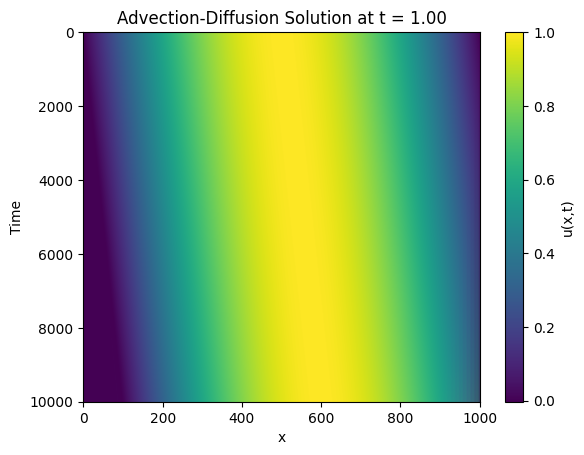

In [41]:
def advection_diffusion(u, C, D, dx):
    """
    Compute the new time derivative of the solution given the equation coefficients C, D and the current solution u.
    """
    # Compute the spatial derivatives with centered finite differences
    du_dx = (u[2:] - u[:-2]) / (2 * dx)  # First derivative
    du_dxx = (u[2:] - 2 *u[1:-1] + u[:-2]) / (dx ** 2)  # Second derivative

    # Compute the time derivative using the advection-diffusion equation
    du_dt = C * du_dx + D * du_dxx
    
    return du_dt

# Define coefficients
C = -0.1  # Advection coefficient
D = 0  # Diffusion coefficient

dx, dt = 0.001, 0.0001
x = np.arange(0, 1 + dx, dx)
t_final = 1.0
t_vet = np.arange(0, t_final + dt, dt)

# Enforcement of boundary conditions
u0 = np.sin(np.pi * x)
u_matrix = np.zeros((int(t_final/dt) + 1, len(x)))
u_matrix[0, :] = u0
u_matrix[:, 0] = 0          # Boundary condition at x=0
u_matrix[:, -1] = 0         # Boundary condition at x=1

# Integration with forward Euler method
for (i, t) in enumerate(t_vet[1:]):
    du_dt = advection_diffusion(u_matrix[i, :], C, D, dx)
    u_matrix[i+1, 1:-1] = u_matrix[i, 1:-1] + du_dt * dt

# Plot the results on a heatmap to resemble 3d graph
plt.imshow(u_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('Time')
plt.title('Advection-Diffusion Solution at t = {:.2f}'.format(t_final))
plt.show()

### Training

In [58]:
# Here I wrote the model so that Idon't have to import the file every time, and restart the kernel.
# Onche the model is finalized, it should be moved in models.py

from models import FNN, dtype, device
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import trange

class ModelDiscovery(FNN):
    def __init__(self, layers, activation=nn.Tanh):
        """
        In Model discovery f_theta is a function of both x and t, therefore make sure the input
        dimension considers also the time variable.

        Bare in Mind that usually xt[:,0] is the timevariable, the spatial variable is xt[:,1]
        """
        super().__init__(layers, activation)
        # self.A = nn.Parameter(torch.tensor(1, dtype=dtype, device=device, requires_grad=True))
        # self.B = nn.Parameter(torch.tensor(1, dtype=dtype, device=device, requires_grad=True))
        self.C = nn.Parameter(torch.tensor(1, dtype=dtype, device=device, requires_grad=True))
        self.D = nn.Parameter(torch.tensor(1, dtype=dtype, device=device, requires_grad=True))

    def model_loss(self, xt_train, y_train, lam_pde, lam_mse):
        # ---- Compute Gradients ----
        xt = xt_train.clone().detach().requires_grad_(True)
        y = self.forward(xt)
        grads = torch.autograd.grad(y.sum(), xt, create_graph=True)[0]
        dy_dt = grads[:, 0]
        dy_dx = grads[:, 1]
        dy_dxx = torch.autograd.grad(dy_dx.sum(), xt, create_graph=True)[0][:,1]
        
        # ---- PDE and MSE Loss ----
        pde_loss = torch.mean((dy_dt - self.C * dy_dx - self.D * dy_dxx) ** 2)
        mse_loss = self.loss_fn(y, y_train)

        return lam_pde * pde_loss + lam_mse * mse_loss

    def train_model(self, xt_train, y_train, epochs=1000, lr=1e-3, batch_size=256, lam_pde=0.5, lam_mse=0.5,
                    track_loss=False, xt_val=None, y_val=None, lr_change=None):
        
        # ---- Safety Check ----
        if len(y_train.shape) == 1:
            y_train = y_train.unsqueeze(1)
        assert y_train.shape[1] == 1, "y_train should have only 1 column"
        if len(y_val.shape) == 1:
            y_val = y_val.unsqueeze(1)
        assert y_val.shape[1] == 1, "y_val should have only 1 column"

        optimizer = optim.Adam(self.parameters(), lr=lr)  # Using Adam optimizer. parameters is hereded from nn.Module
        if track_loss:
            loss_history = []
            val_loss = []

        # ---- Create DataLoader for batch training ----
        batch = torch.randperm(xt_train.size(0))[:batch_size]
        xt_train, y_train = xt_train[batch], y_train[batch]

        # ---- Training Loop with Progress Bar ----
        epochs = trange(epochs, desc="Training Epoch: ")
        for epoch in epochs:
            # Check if is time to change learning rate
            if lr_change is not None and epoch == lr_change[0]:
                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr_change[1]

            self.train()  # Set the model to training mode
            
            # for xt_train_batch, y_train_batch in train_loader:
            #     optimizer.zero_grad()
            #     loss = self.model_loss(xt_train_batch, y_train_batch)
            #     loss.backward()
            #     optimizer.step()
            
            optimizer.zero_grad()
            loss = self.model_loss(xt_train, y_train, lam_pde, lam_mse)
            loss.backward()
            optimizer.step()


            if track_loss:
                with torch.no_grad():
                    y_pred_val = self.forward(xt_val)
                    val_loss.append(self.loss_fn(y_pred_val, y_val).item())
                loss_history.append(loss.item())

            # Create a postfix to show val and train loss in the progress bar
            epochs.set_postfix({'train_loss': loss.item(), 'val_loss': val_loss[-1] if track_loss else 'N/A'}) 
        
        if track_loss:
            return self.C.item(), self.D.item(), loss_history, val_loss


In [46]:
# Lets convert the data from the PDE to trainable data for SINDy
xt, tt = np.meshgrid(x, t_vet)
X_numpy = np.column_stack((tt.flatten(), xt.flatten()))
U_numpy = u_matrix.flatten()
print(U_numpy.shape)

(10011001,)


In [57]:
X, U = torch.tensor(X_numpy, device=device, dtype=dtype), torch.tensor(U_numpy, device=device, dtype=dtype)
xt_train, xt_test, U_train, U_test = train_test_split(X, U, test_size=0.1, random_state=42)

sindy = ModelDiscovery(layers=[2, 128, 128, 1]).to(device=device, dtype=dtype)

C_disc, D_disc, loss_history, val_loss = sindy.train_model(
    xt_train, U_train,
    lr=1e-2, 
    batch_size=4096, 
    epochs=1000, 
    track_loss=True, 
    xt_val=xt_test, y_val=U_test
    )


Training Epoch: 100%|██████████| 1000/1000 [06:33<00:00,  2.54it/s, train_loss=0.000737, val_loss=0.000938]


Discovered coefficients: C_disc = -0.1005, D_disc = 0.0007


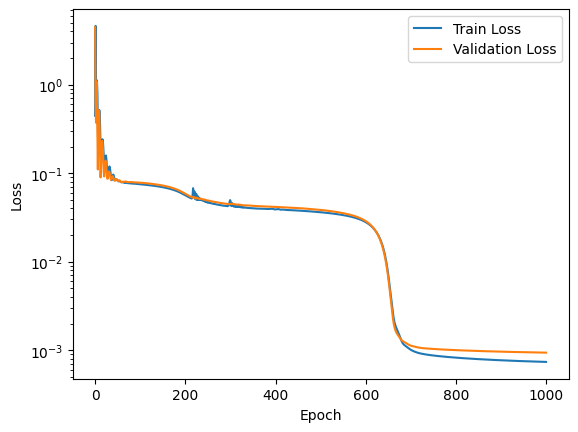

In [59]:
print(f"Discovered coefficients: C_disc = {C_disc:.4f}, D_disc = {D_disc:.4f}")
plt.semilogy(loss_history, label='Train Loss')
plt.semilogy(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

<function matplotlib.pyplot.colorbar(mappable: 'ScalarMappable | ColorizingArtist | None' = None, cax: 'matplotlib.axes.Axes | None' = None, ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None, **kwargs) -> 'Colorbar'>

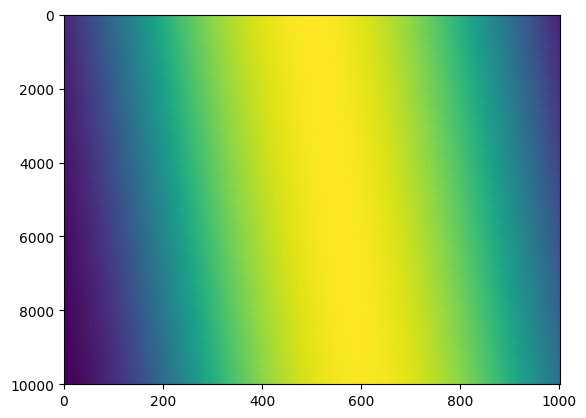

In [66]:
eval_batch = 100_000
u_pred = np.zeros_like(U_numpy)
for i in range(0, X.size(0), eval_batch):
    u_pred[i:i+eval_batch] = sindy.predict(X[i:i+eval_batch]).detach().flatten().cpu().numpy()
    
u_pred_matrix = u_pred.reshape(u_matrix.shape)
plt.imshow(u_pred_matrix, aspect='auto', cmap='viridis')
plt.colorbar